In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

# credit: https://www.pythoncharts.com/matplotlib/beautiful-bar-charts-matplotlib/


#### Global plotting style

In [23]:
# ---------------------------------
# High-resolution notebook display
# ---------------------------------
set_matplotlib_formats('retina')

# ---------------------------------
# Global plotting style
# ---------------------------------

# Optional: rebuild font cache once if needed
# mpl.font_manager._rebuild()

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,

    # Figure
    "figure.figsize": (8, 5),
    "figure.dpi": 120,

    # Axes
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,

    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#333333",
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.labelsize": 10,

    # Grid
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#EEEEEE",
    "grid.linestyle": "-",
    "grid.linewidth": 1.0,

    # Ticks
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
})


#### Data prep

In [24]:
# ---------------------------------
# Load CSV
# ---------------------------------
df = pd.read_csv("data/incl_data/All studies.csv")

# ---------------------------------
# Clean column names
# ---------------------------------
df.columns = (
    df.columns
    .str.replace(r'[\n\r\t]+', '', regex=True)
    .str.strip()
)

# ---------------------------------
# Clean Year column
# ---------------------------------
df["Year"] = (
    df["Year"]
    .astype(str)
    .str.replace(r'[\n\r\t ]+', '', regex=True)
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Keep valid years
df = df[df["Year"].between(2022, 2026)]


##### Annual publication distribution across included studies (2022--2026).

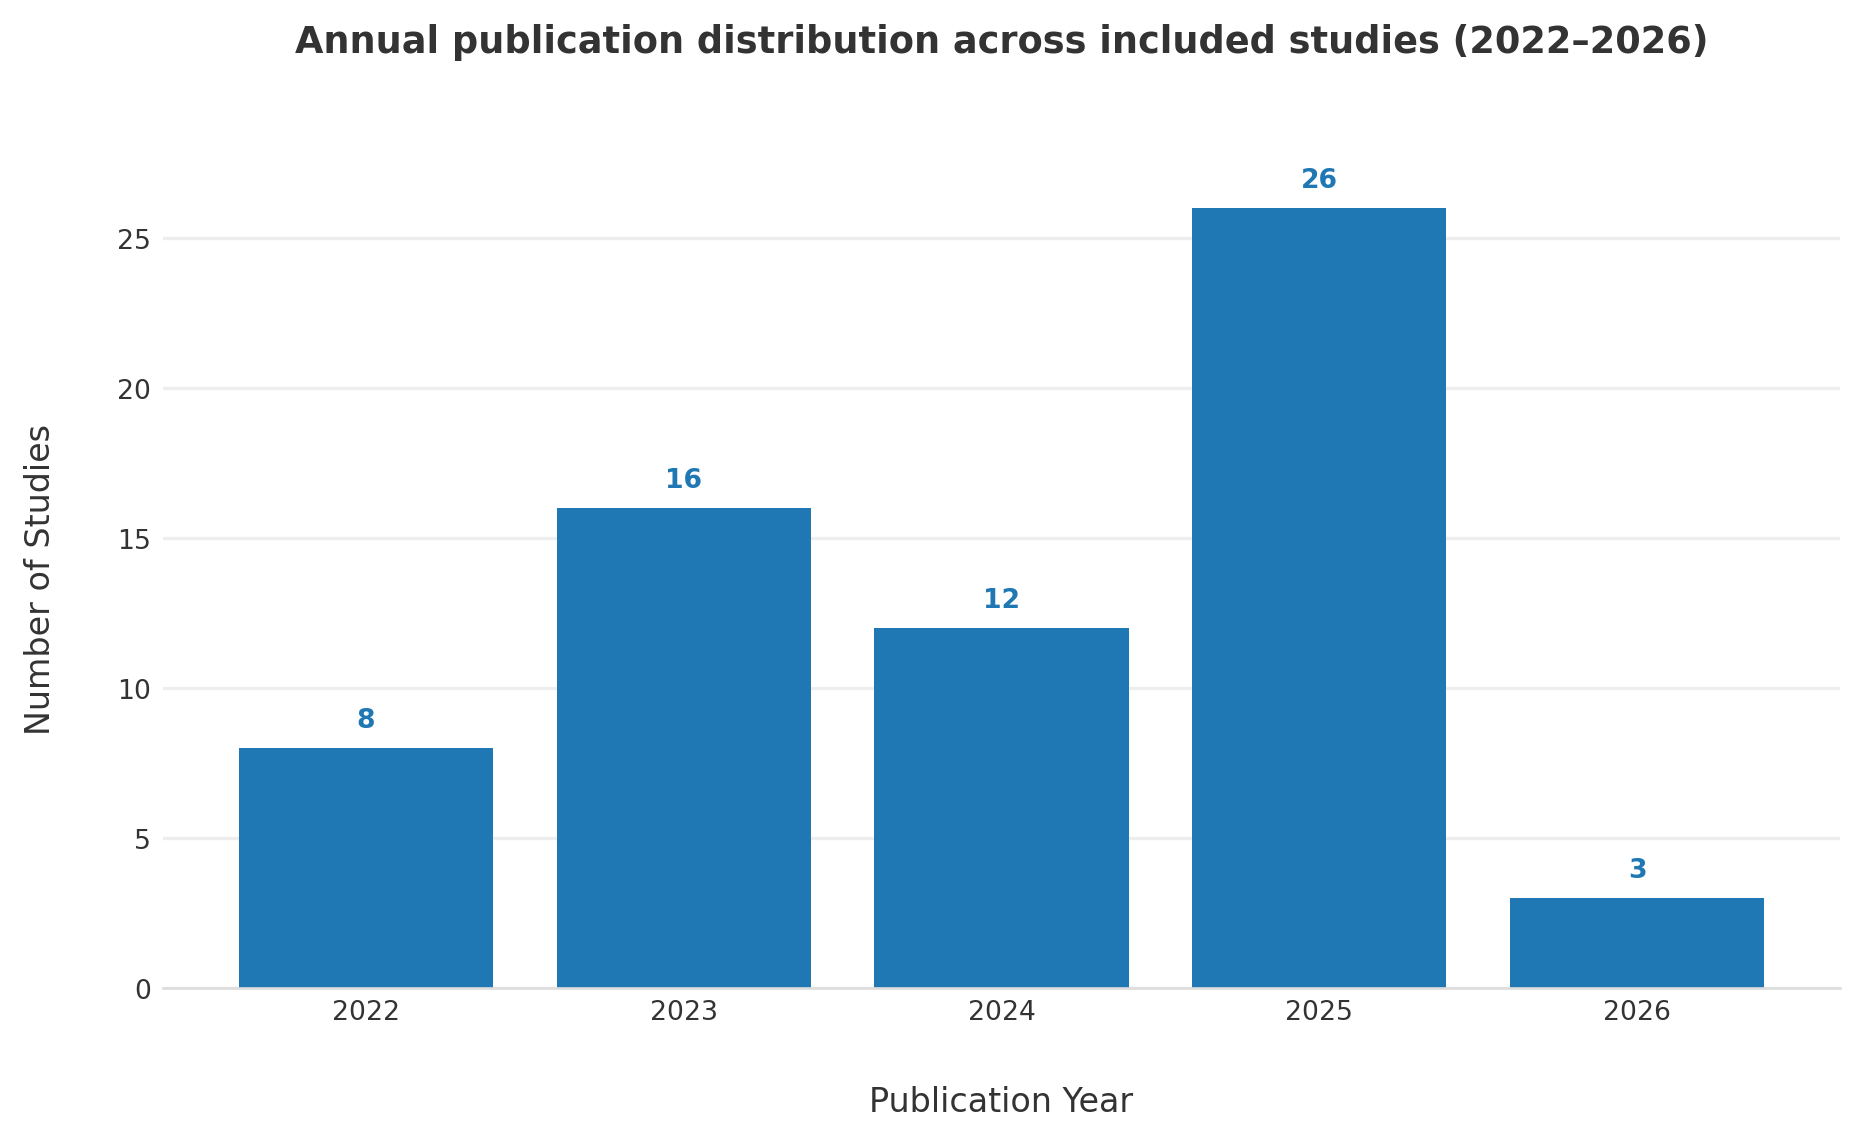

In [25]:
# ---------------------------------
# Count publications per year
# ---------------------------------
year_counts = (
    df["Year"]
    .value_counts()
    .sort_index()
)

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots()

bars = ax.bar(
    x=np.arange(len(year_counts)),
    height=year_counts.values,
    tick_label=year_counts.index.astype(str)
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['bottom'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color='#EEEEEE')
ax.xaxis.grid(False)

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Publication Year",
    labelpad=18,
    color='#333333'
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18,
    color='#333333'
)

ax.set_title(
    "Annual publication distribution across included studies (2022–2026)",
    pad=35,
    color='#333333',
    weight='bold'
)

# ---------------------------------
# Add value labels above bars
# ---------------------------------
bar_color = bars[0].get_facecolor()

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        color=bar_color,
        weight='bold'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout(pad=2)

# ---------------------------------
# Create output directory
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

# ---------------------------------
# Save figure
# ---------------------------------
plt.savefig(
    "data/figures/litRES/annual_publication_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Accelerometer         10
Gyroscope              6
Magnetometer           2
Heart-rate sensor      3
Temperature sensor     1
GPS                    3
SpO2 sensor            1
dtype: int64


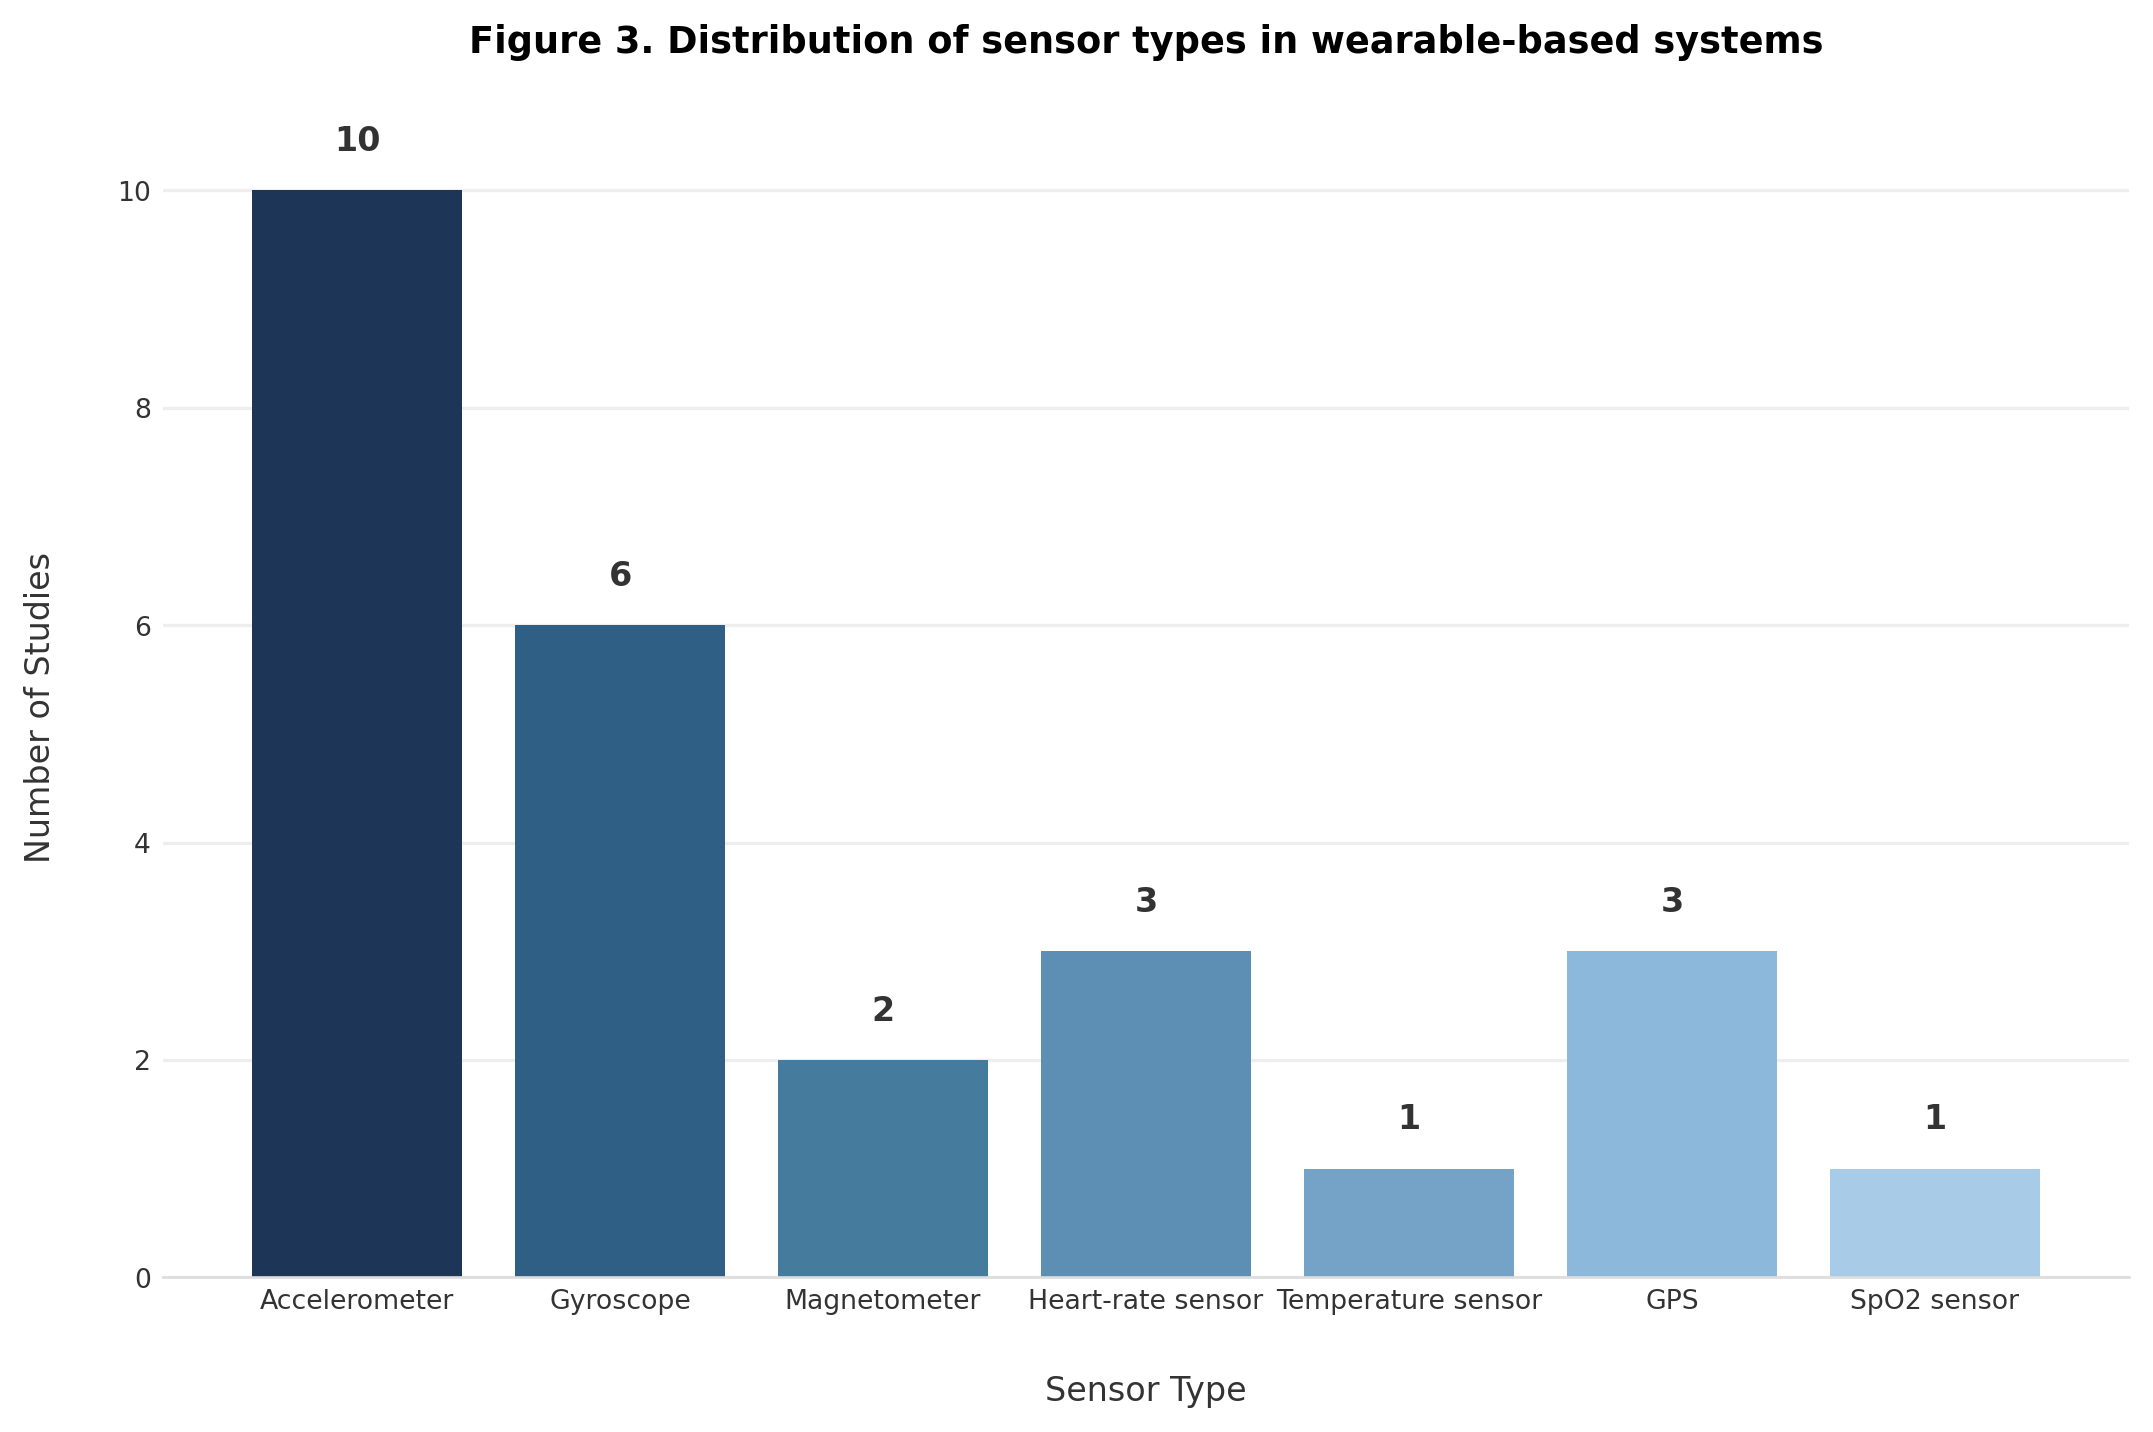

In [26]:
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Keep only wearable-based studies
# ---------------------------------
wearable_df = df[df["Sensor modality"] == "Wearable"].copy()

# ---------------------------------
# Column containing sensor info
# ---------------------------------
sensor_col = "Sensor type"

# ---------------------------------
# Clean text
# ---------------------------------
wearable_df[sensor_col] = (
    wearable_df[sensor_col]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# ---------------------------------
# Extract and count sensors
# ---------------------------------
all_sensors = []

for item in wearable_df[sensor_col]:

    # Split multiple sensors in same cell
    parts = re.split(r'[,;/]', item)

    for p in parts:
        p = p.strip()

        if p:
            all_sensors.append(p)

# ---------------------------------
# Count occurrences
# ---------------------------------
sensor_counts = pd.Series(Counter(all_sensors))

# Desired order
sensor_order = [
    "Accelerometer",
    "Gyroscope",
    "Magnetometer",
    "Heart-rate sensor",
    "Temperature sensor",
    "GPS",
    "SpO2 sensor"
]

sensor_counts = sensor_counts.reindex(sensor_order).fillna(0)

print(sensor_counts)

# ---------------------------------
# Gradient color palette
# ---------------------------------
colors = [
    "#1d3557",
    "#2f5f85",
    "#457b9d",
    "#5c8fb3",
    "#74a3c7",
    "#8cb8db",
    "#a8cbe8"
]

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    sensor_counts.index,
    sensor_counts.values,
    color=colors
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color="#EEEEEE")
ax.xaxis.grid(False)

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Sensor Type",
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18
)

ax.set_title(
    "Figure 3. Distribution of sensor types in wearable-based systems",
    pad=25
)

# ---------------------------------
# Add labels above bars
# ---------------------------------
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
        color='#333333'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Save figure
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/sensor_distribution_wearable.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

mmWave/FMCW radar             12
Acoustic                       2
Wi-Fi CSI                      7
UWB radar                      2
Vibration/Pressure sensing     2
Passive Wi-Fi radar            2
Electrostatic sensor           1
Infrared (IR)                  1
dtype: int64


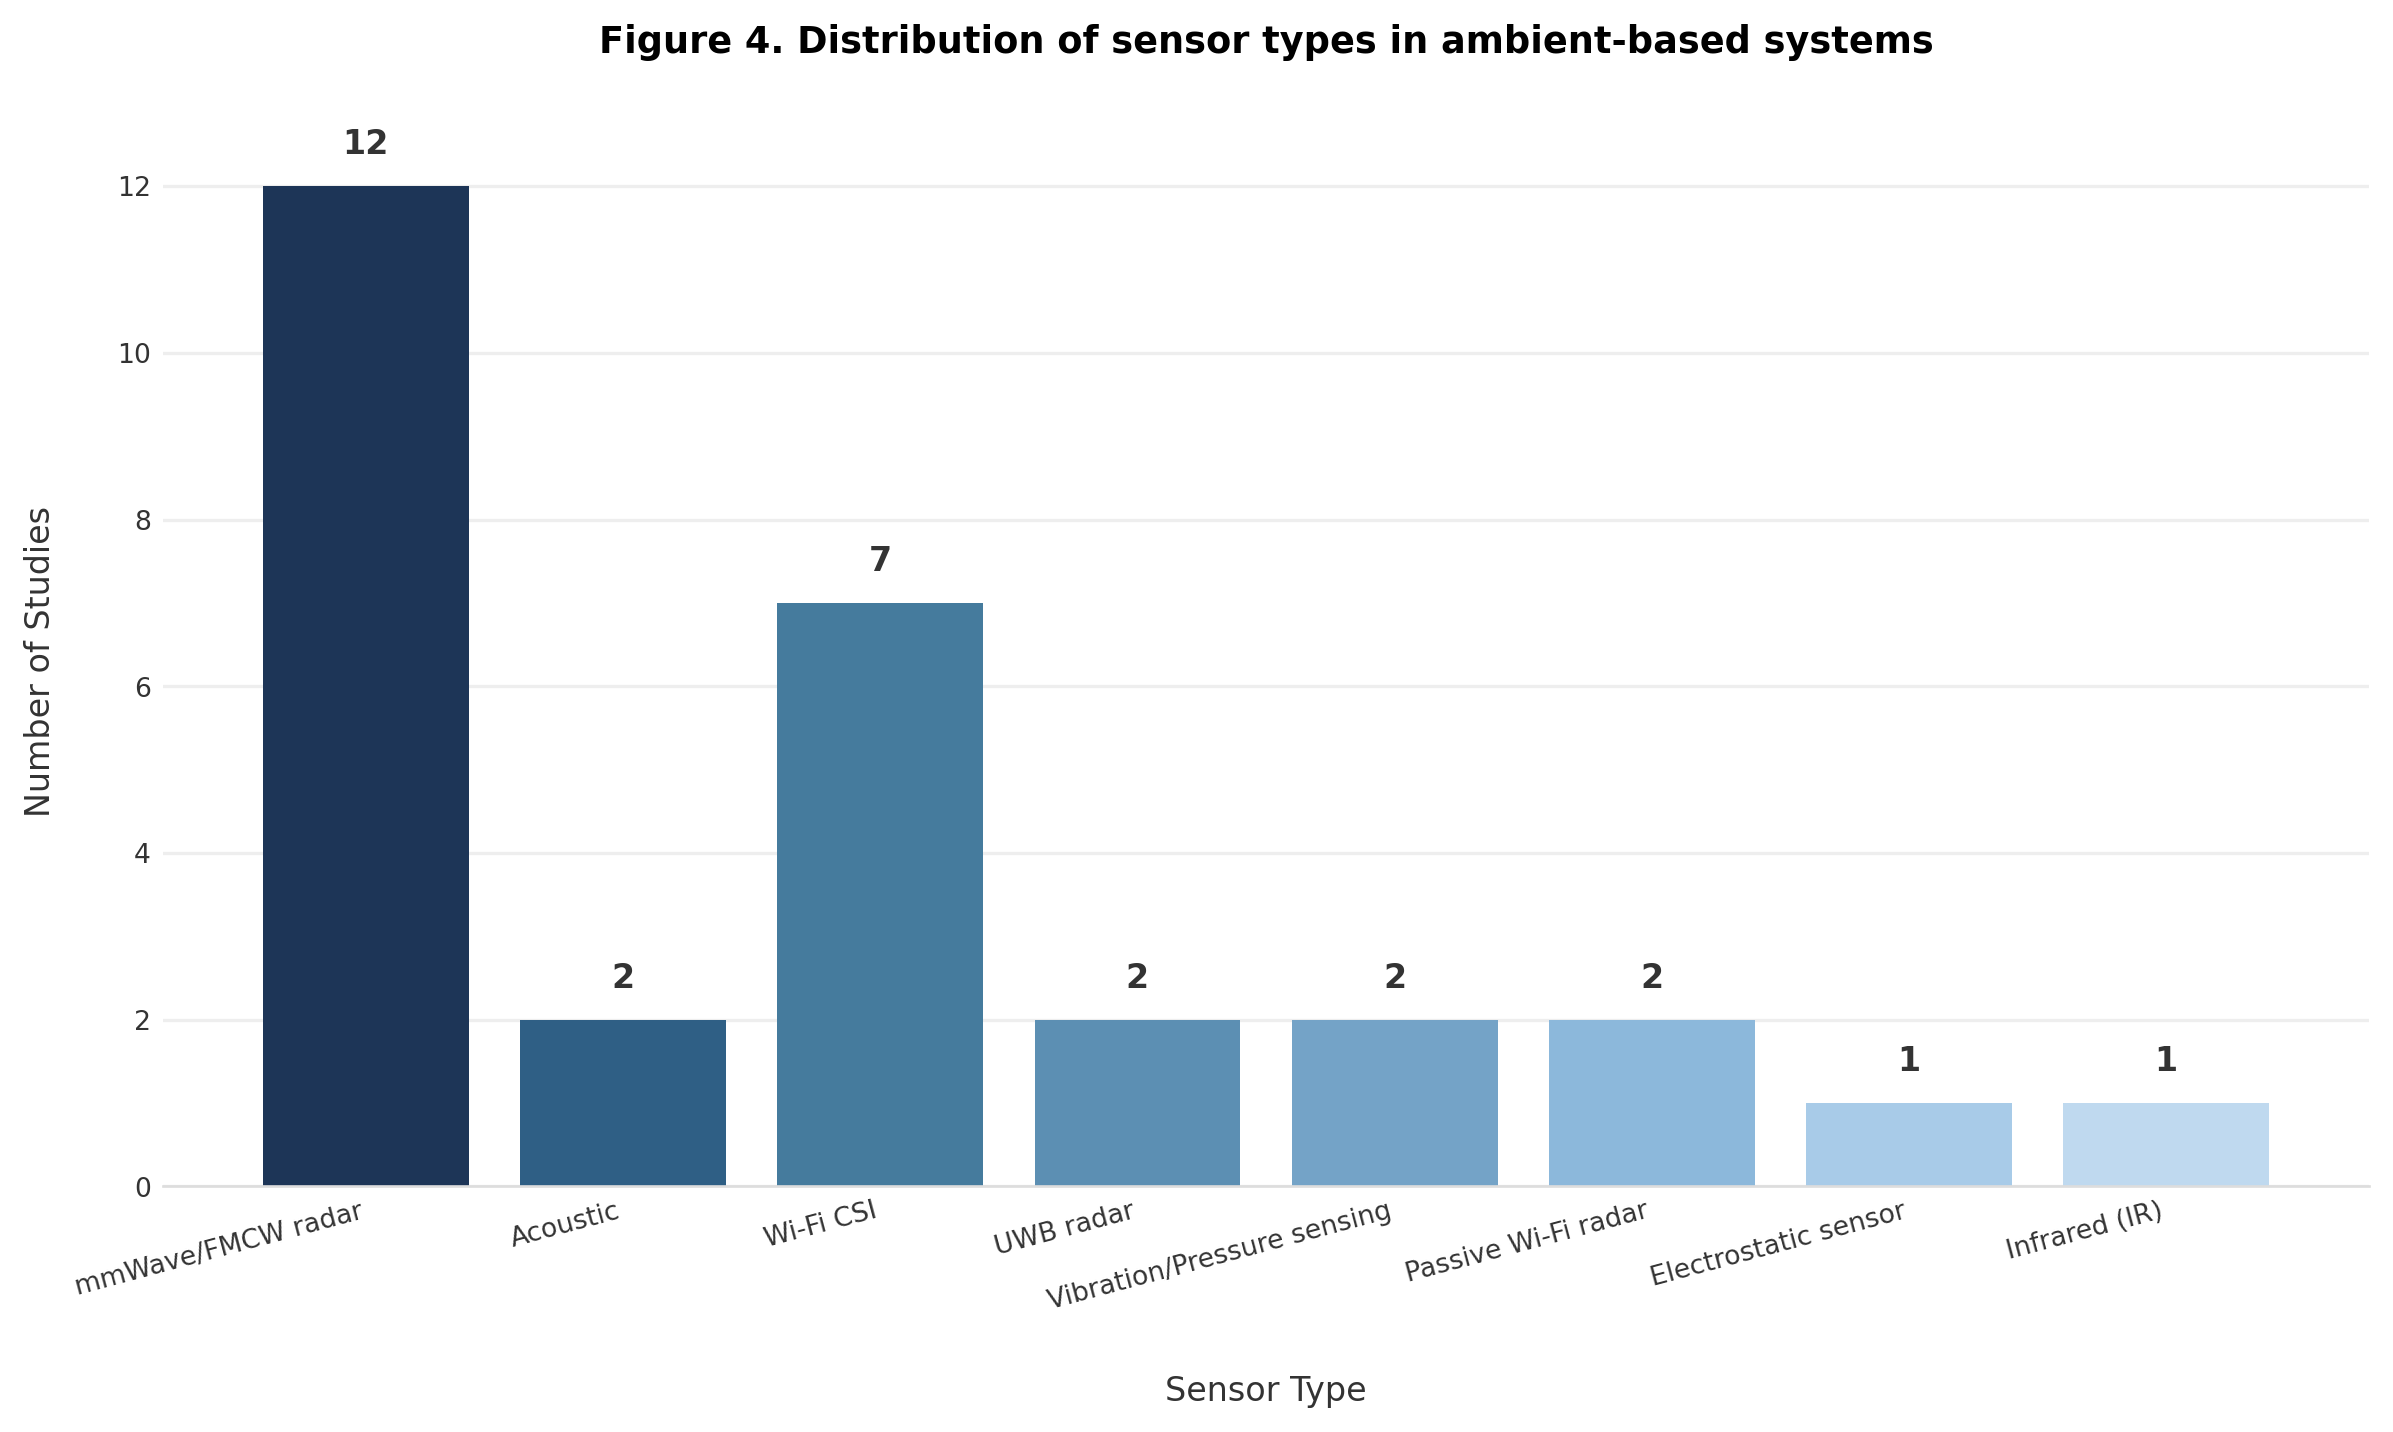

In [27]:
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ---------------------------------
# Keep ONLY ambient-only studies
# ---------------------------------
ambient_df = df[
    df["Sensor modality"]
    .astype(str)
    .str.strip()
    .eq("Ambient")
].copy()

# ---------------------------------
# Column containing sensor info
# ---------------------------------
sensor_col = "Sensor type"

# ---------------------------------
# Clean text
# ---------------------------------
ambient_df[sensor_col] = (
    ambient_df[sensor_col]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# ---------------------------------
# Extract and count sensors
# ---------------------------------
all_sensors = []

for item in ambient_df[sensor_col]:

    # Split multiple sensors in same cell
    parts = re.split(r'[,;/]', item)

    for p in parts:

        p = p.strip()

        # ---------------------------------
        # Merge radar categories
        # ---------------------------------
        if (
            p == "mmWave/FMCW radar"
            or p == "mmWave radar"
            or p == "FMCW radar"
        ):
            all_sensors.append("mmWave/FMCW radar")

        # ---------------------------------
        # Merge vibration categories
        # ---------------------------------
        elif (
            p == "Vibration sensing"
            or p == "Pressure sensing"
            or p == "Vibration/Pressure sensing"
        ):
            all_sensors.append("Vibration/Pressure sensing")

        elif p:
            all_sensors.append(p)

# ---------------------------------
# Count occurrences
# ---------------------------------
sensor_counts = pd.Series(Counter(all_sensors))

# Desired order
sensor_order = [
    "mmWave/FMCW radar",
    "Acoustic",
    "Wi-Fi CSI",
    "UWB radar",
    "Vibration/Pressure sensing",
    "Passive Wi-Fi radar",
    "Electrostatic sensor",
    "Infrared (IR)"
]

sensor_counts = sensor_counts.reindex(sensor_order).fillna(0)

print(sensor_counts)

# ---------------------------------
# Gradient color palette
# ---------------------------------
colors = [
    "#1d3557",
    "#2f5f85",
    "#457b9d",
    "#5c8fb3",
    "#74a3c7",
    "#8cb8db",
    "#a8cbe8",
    "#bfd9ef"
]

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    sensor_counts.index,
    sensor_counts.values,
    color=colors
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color="#EEEEEE")
ax.xaxis.grid(False)

plt.xticks(rotation=15, ha='right')

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Sensor Type",
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18
)

ax.set_title(
    "Figure 4. Distribution of sensor types in ambient-based systems",
    pad=25
)

# ---------------------------------
# Add labels above bars
# ---------------------------------
for bar in bars:

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
        color='#333333'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Save figure
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/sensor_distribution_ambient.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Modality combination
Ambient + Vision               3
Vision + Wearable              3
Ambient + Wearable             1
Ambient + Vision + Wearable    1
Name: count, dtype: int64


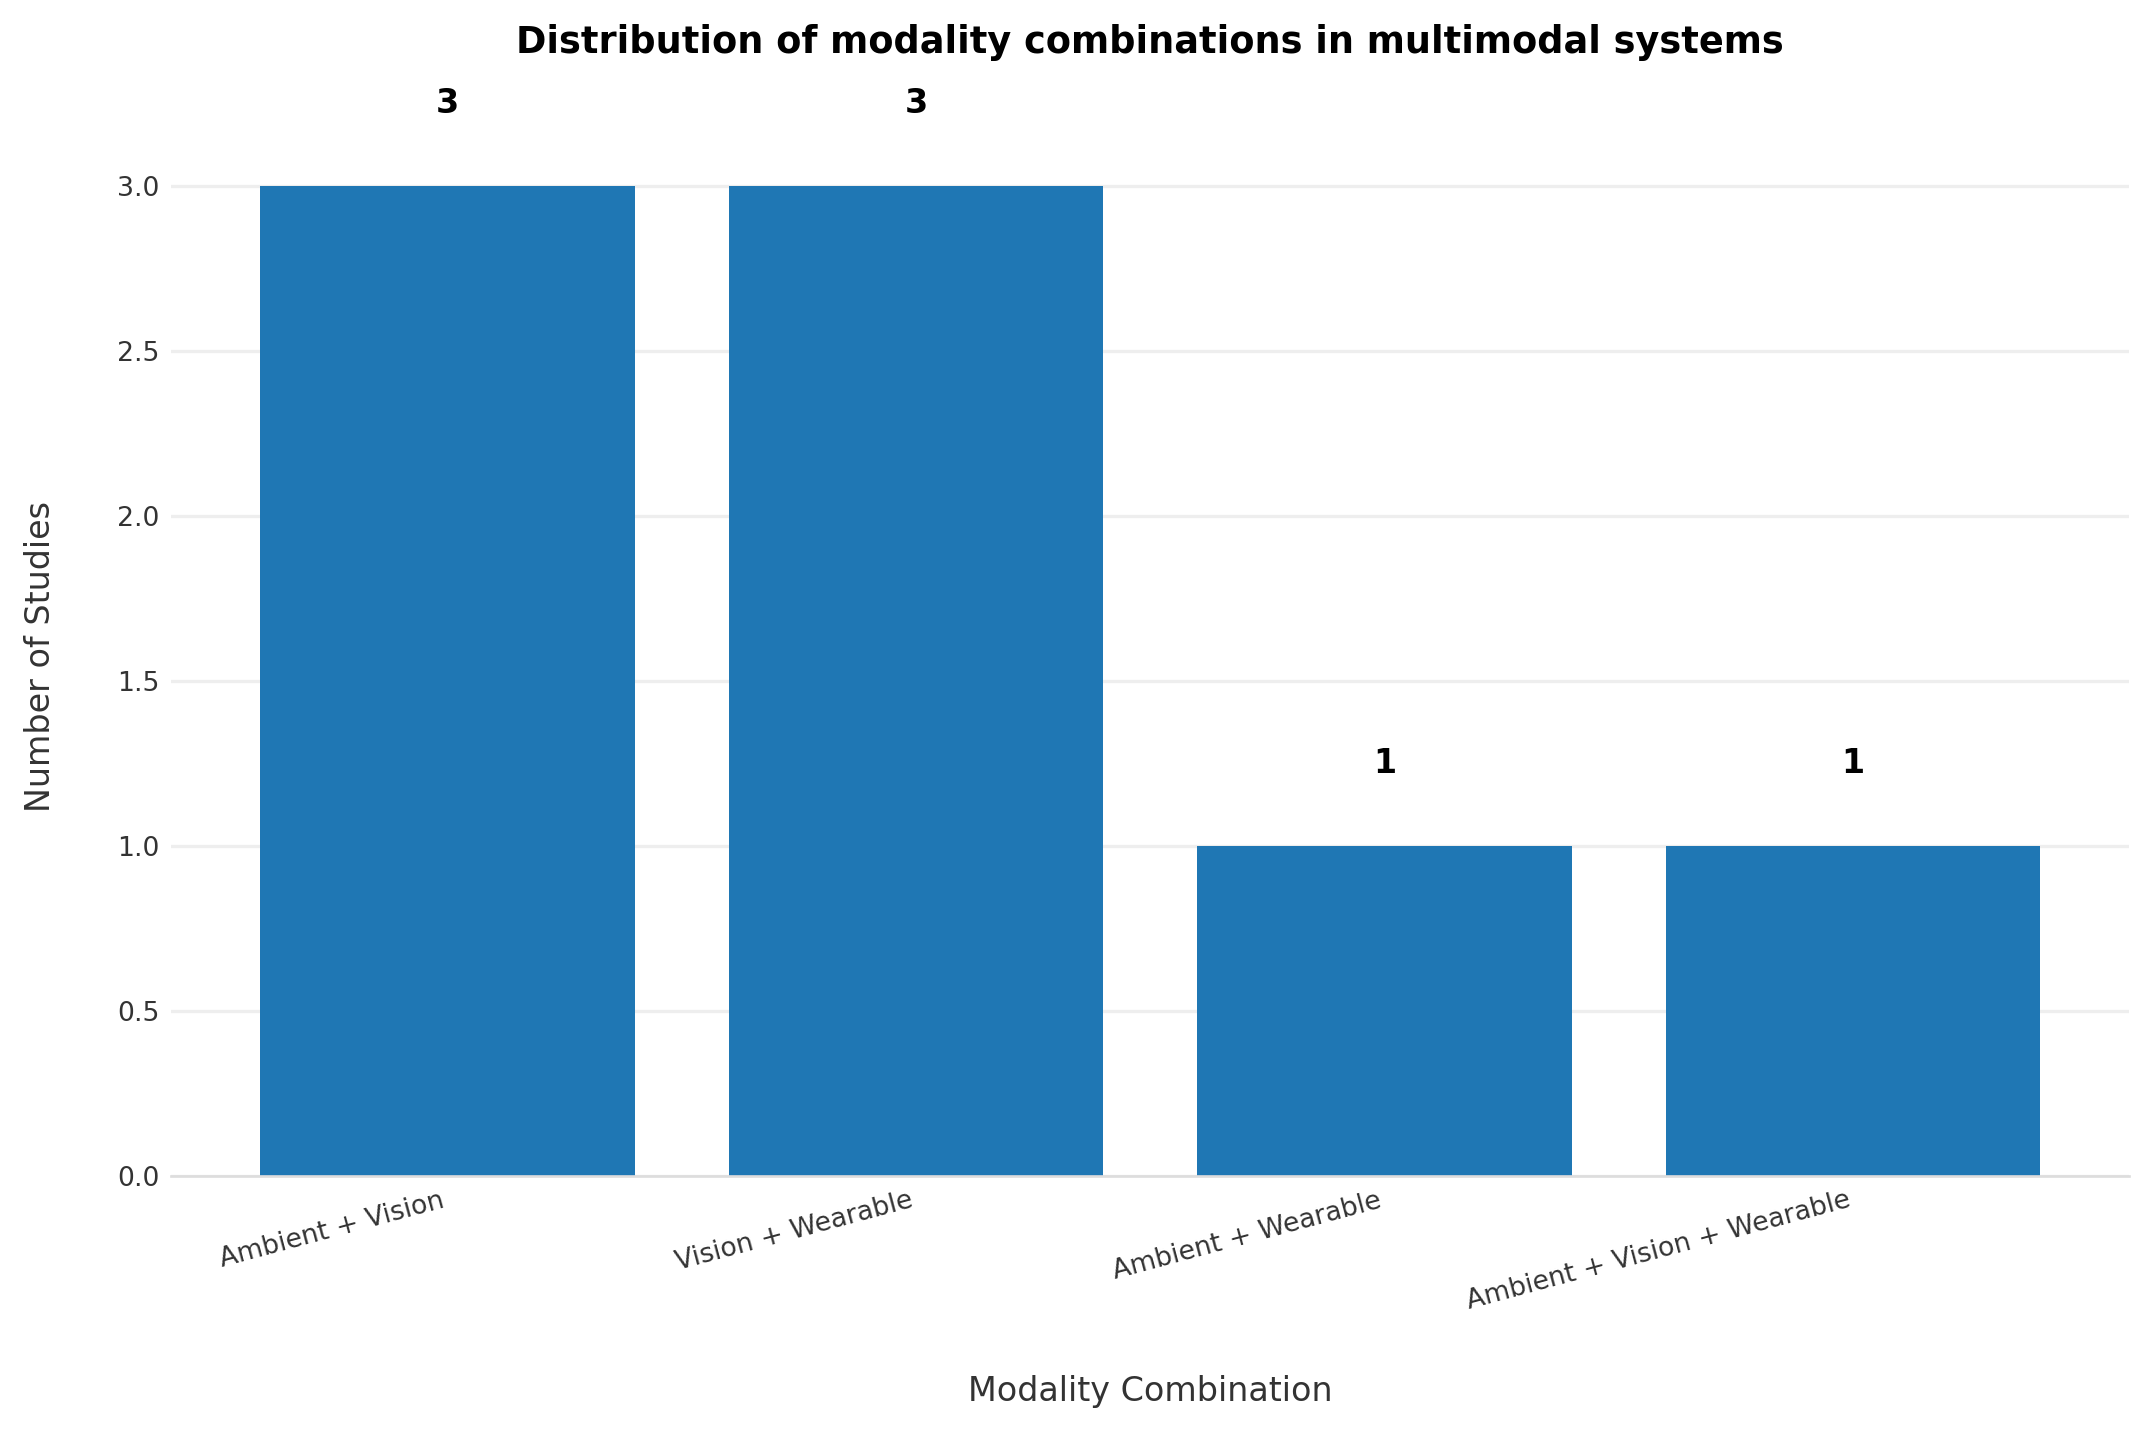

In [28]:
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# Keep only multimodal studies
# ---------------------------------
multimodal_df = df[
    df["Sensor modality"]
    .astype(str)
    .str.contains(";")
].copy()

# ---------------------------------
# Clean modality text
# ---------------------------------
multimodal_df["Sensor modality"] = (
    multimodal_df["Sensor modality"]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# ---------------------------------
# Standardize modality combinations
# ---------------------------------
def normalize_modalities(modality_string):

    # Split modalities
    mods = [
        m.strip()
        for m in modality_string.split(";")
    ]

    # Sort alphabetically for consistency
    mods = sorted(mods)

    # Rejoin
    return " + ".join(mods)

# ---------------------------------
# Apply normalization
# ---------------------------------
multimodal_df["Modality combination"] = (
    multimodal_df["Sensor modality"]
    .apply(normalize_modalities)
)

# ---------------------------------
# Count combinations
# ---------------------------------
combo_counts = (
    multimodal_df["Modality combination"]
    .value_counts()
)

print(combo_counts)

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    combo_counts.index,
    combo_counts.values
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color="#EEEEEE")
ax.xaxis.grid(False)

plt.xticks(rotation=15, ha='right')

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Modality Combination",
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18
)

ax.set_title(
    "Distribution of modality combinations in multimodal systems",
    pad=25
)

# ---------------------------------
# Add labels above bars
# ---------------------------------
for bar in bars:

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Save figure
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/multimodal_combinations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Dataset typ
Public datasets           21
Custom datasets           40
Hybrid/Public + Custom     4
Name: count, dtype: int64


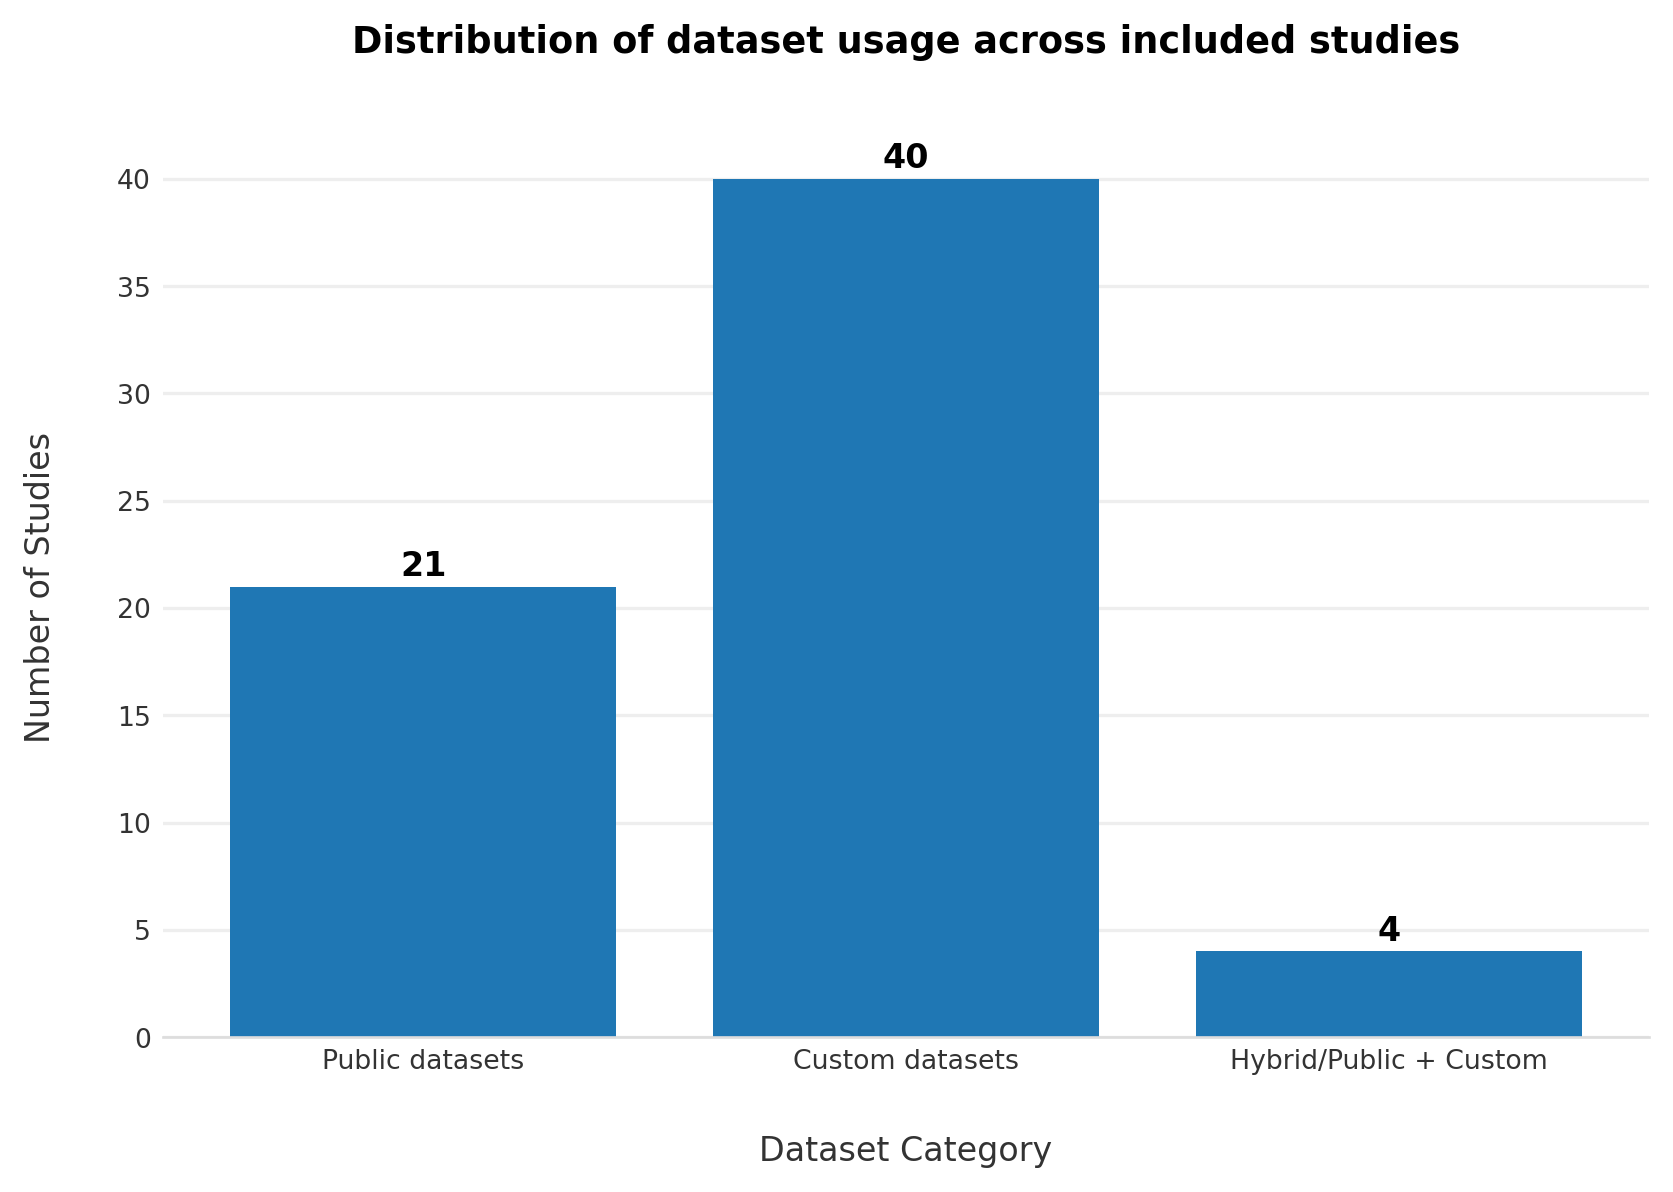

Dataset typ  Public datasets  Custom datasets  Hybrid/Public + Custom
Modality                                                             
Ambient                    4               28                       2
Vision                    12               10                       3
Wearable                  11                4                       0


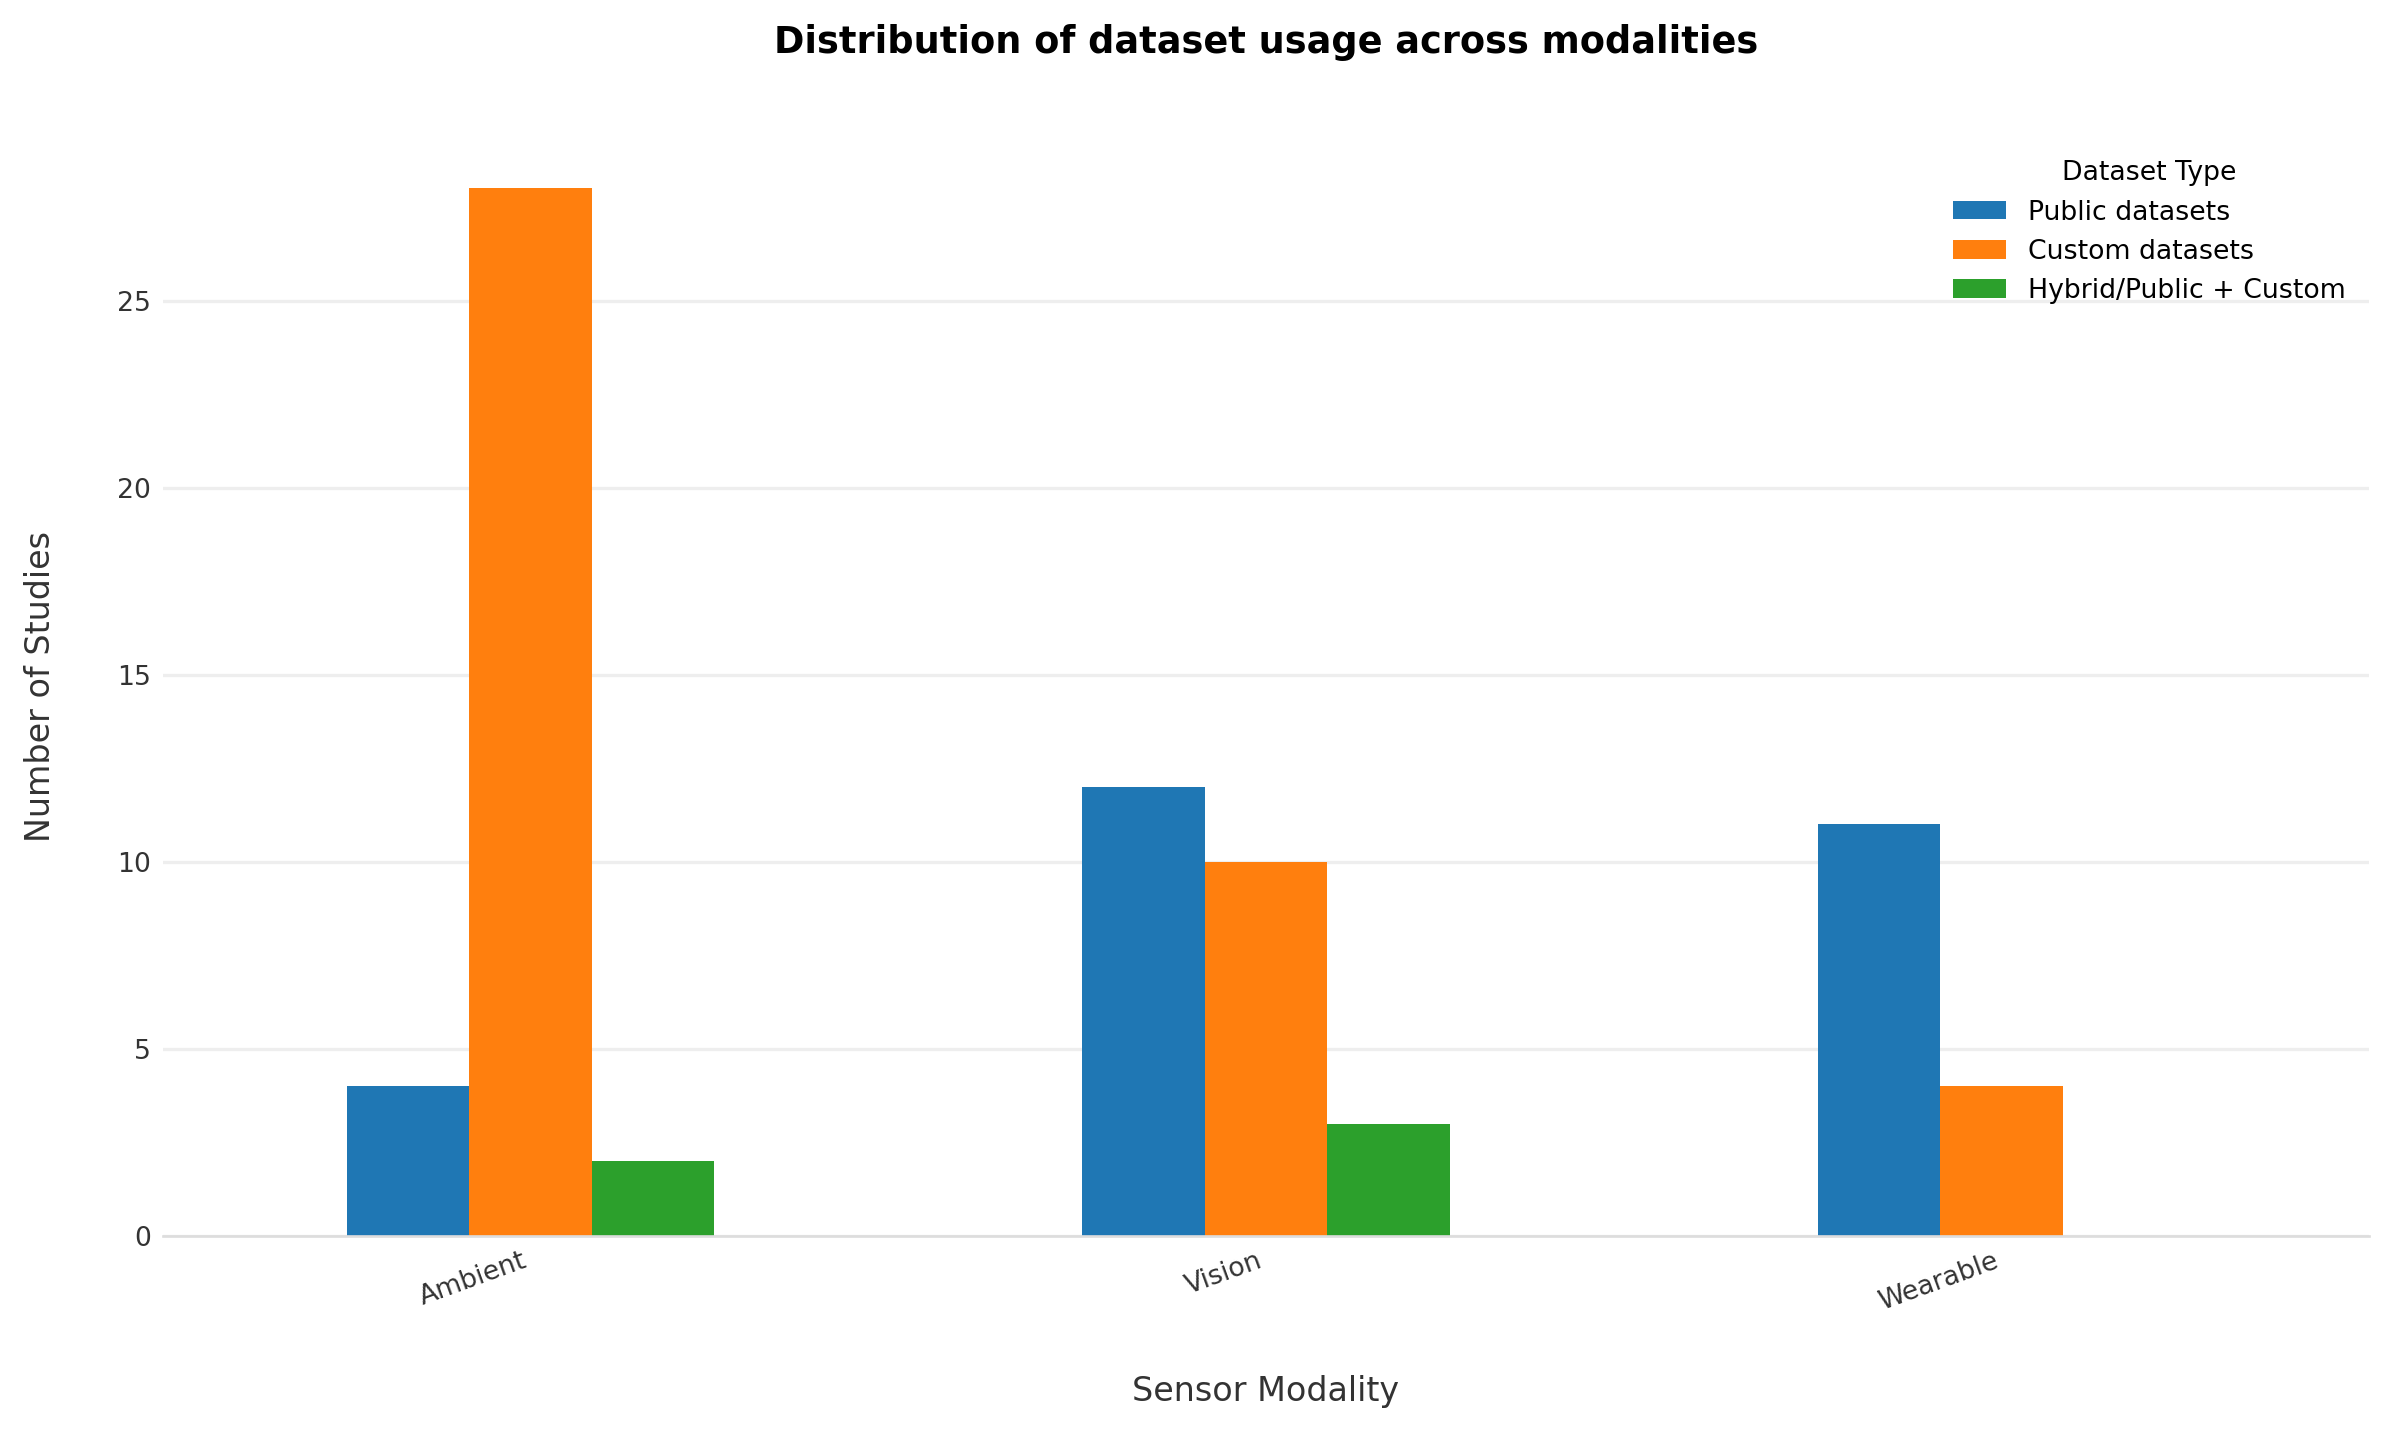

In [29]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# FIGURE X
# Distribution of dataset usage across included studies
# =========================================================

# ---------------------------------
# Clean dataset type column
# ---------------------------------
dataset_df = df.copy()

dataset_df["Dataset typ"] = (
    dataset_df["Dataset typ"]
    .astype(str)
    .str.strip()
    .replace({
        "Mix": "Hybrid/Public + Custom",
        "Public": "Public datasets",
        "Custom": "Custom datasets"
    })
)

# ---------------------------------
# Count dataset usage categories
# ---------------------------------
dataset_counts = (
    dataset_df["Dataset typ"]
    .value_counts()
    .reindex([
        "Public datasets",
        "Custom datasets",
        "Hybrid/Public + Custom"
    ])
)

print(dataset_counts)

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    dataset_counts.index,
    dataset_counts.values
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color="#EEEEEE")
ax.xaxis.grid(False)

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Dataset Category",
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18
)

ax.set_title(
    "Distribution of dataset usage across included studies",
    pad=25
)

# ---------------------------------
# Add labels above bars
# ---------------------------------
for bar in bars:

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Save figure
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/dataset_usage_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================================================
# FIGURE Y
# Distribution of dataset usage across modalities
# =========================================================

# ---------------------------------
# Keep relevant columns only
# ---------------------------------
modality_dataset_df = df[
    ["Sensor modality", "Dataset typ"]
].copy()

# ---------------------------------
# Clean modality column
# ---------------------------------
modality_dataset_df["Sensor modality"] = (
    modality_dataset_df["Sensor modality"]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# ---------------------------------
# Standardize dataset labels
# ---------------------------------
modality_dataset_df["Dataset typ"] = (
    modality_dataset_df["Dataset typ"]
    .astype(str)
    .str.strip()
    .replace({
        "Mix": "Hybrid/Public + Custom",
        "Public": "Public datasets",
        "Custom": "Custom datasets"
    })
)

# ---------------------------------
# Split multimodal entries
# ---------------------------------
expanded_rows = []

for _, row in modality_dataset_df.iterrows():

    modalities = [
        m.strip()
        for m in str(row["Sensor modality"]).split(";")
    ]

    for modality in modalities:

        expanded_rows.append({
            "Modality": modality,
            "Dataset typ": row["Dataset typ"]
        })

expanded_df = pd.DataFrame(expanded_rows)

# ---------------------------------
# Count dataset type per modality
# ---------------------------------
modality_counts = pd.crosstab(
    expanded_df["Modality"],
    expanded_df["Dataset typ"]
)

# ---------------------------------
# Reorder columns
# ---------------------------------
desired_order = [
    "Public datasets",
    "Custom datasets",
    "Hybrid/Public + Custom"
]

modality_counts = modality_counts.reindex(
    columns=desired_order,
    fill_value=0
)

print(modality_counts)

# ---------------------------------
# Create figure
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

modality_counts.plot(
    kind='bar',
    ax=ax
)

# ---------------------------------
# Axis formatting
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

ax.tick_params(
    bottom=False,
    left=False
)

ax.yaxis.grid(True, color="#EEEEEE")
ax.xaxis.grid(False)

plt.xticks(rotation=20, ha='right')

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Sensor Modality",
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    labelpad=18
)

ax.set_title(
    "Distribution of dataset usage across modalities",
    pad=25
)

# ---------------------------------
# Legend
# ---------------------------------
ax.legend(
    title="Dataset Type",
    frameon=False
)

# ---------------------------------
# Layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Save figure
# ---------------------------------
plt.savefig(
    "data/figures/litRES/dataset_usage_by_modality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Dataset typ  Public datasets  Custom datasets  Hybrid/Public + Custom
Modality                                                             
Ambient                    2               26                       1
Vision                     8                8                       2
Wearable                   6                4                       0
Multimodal                 5                2                       1


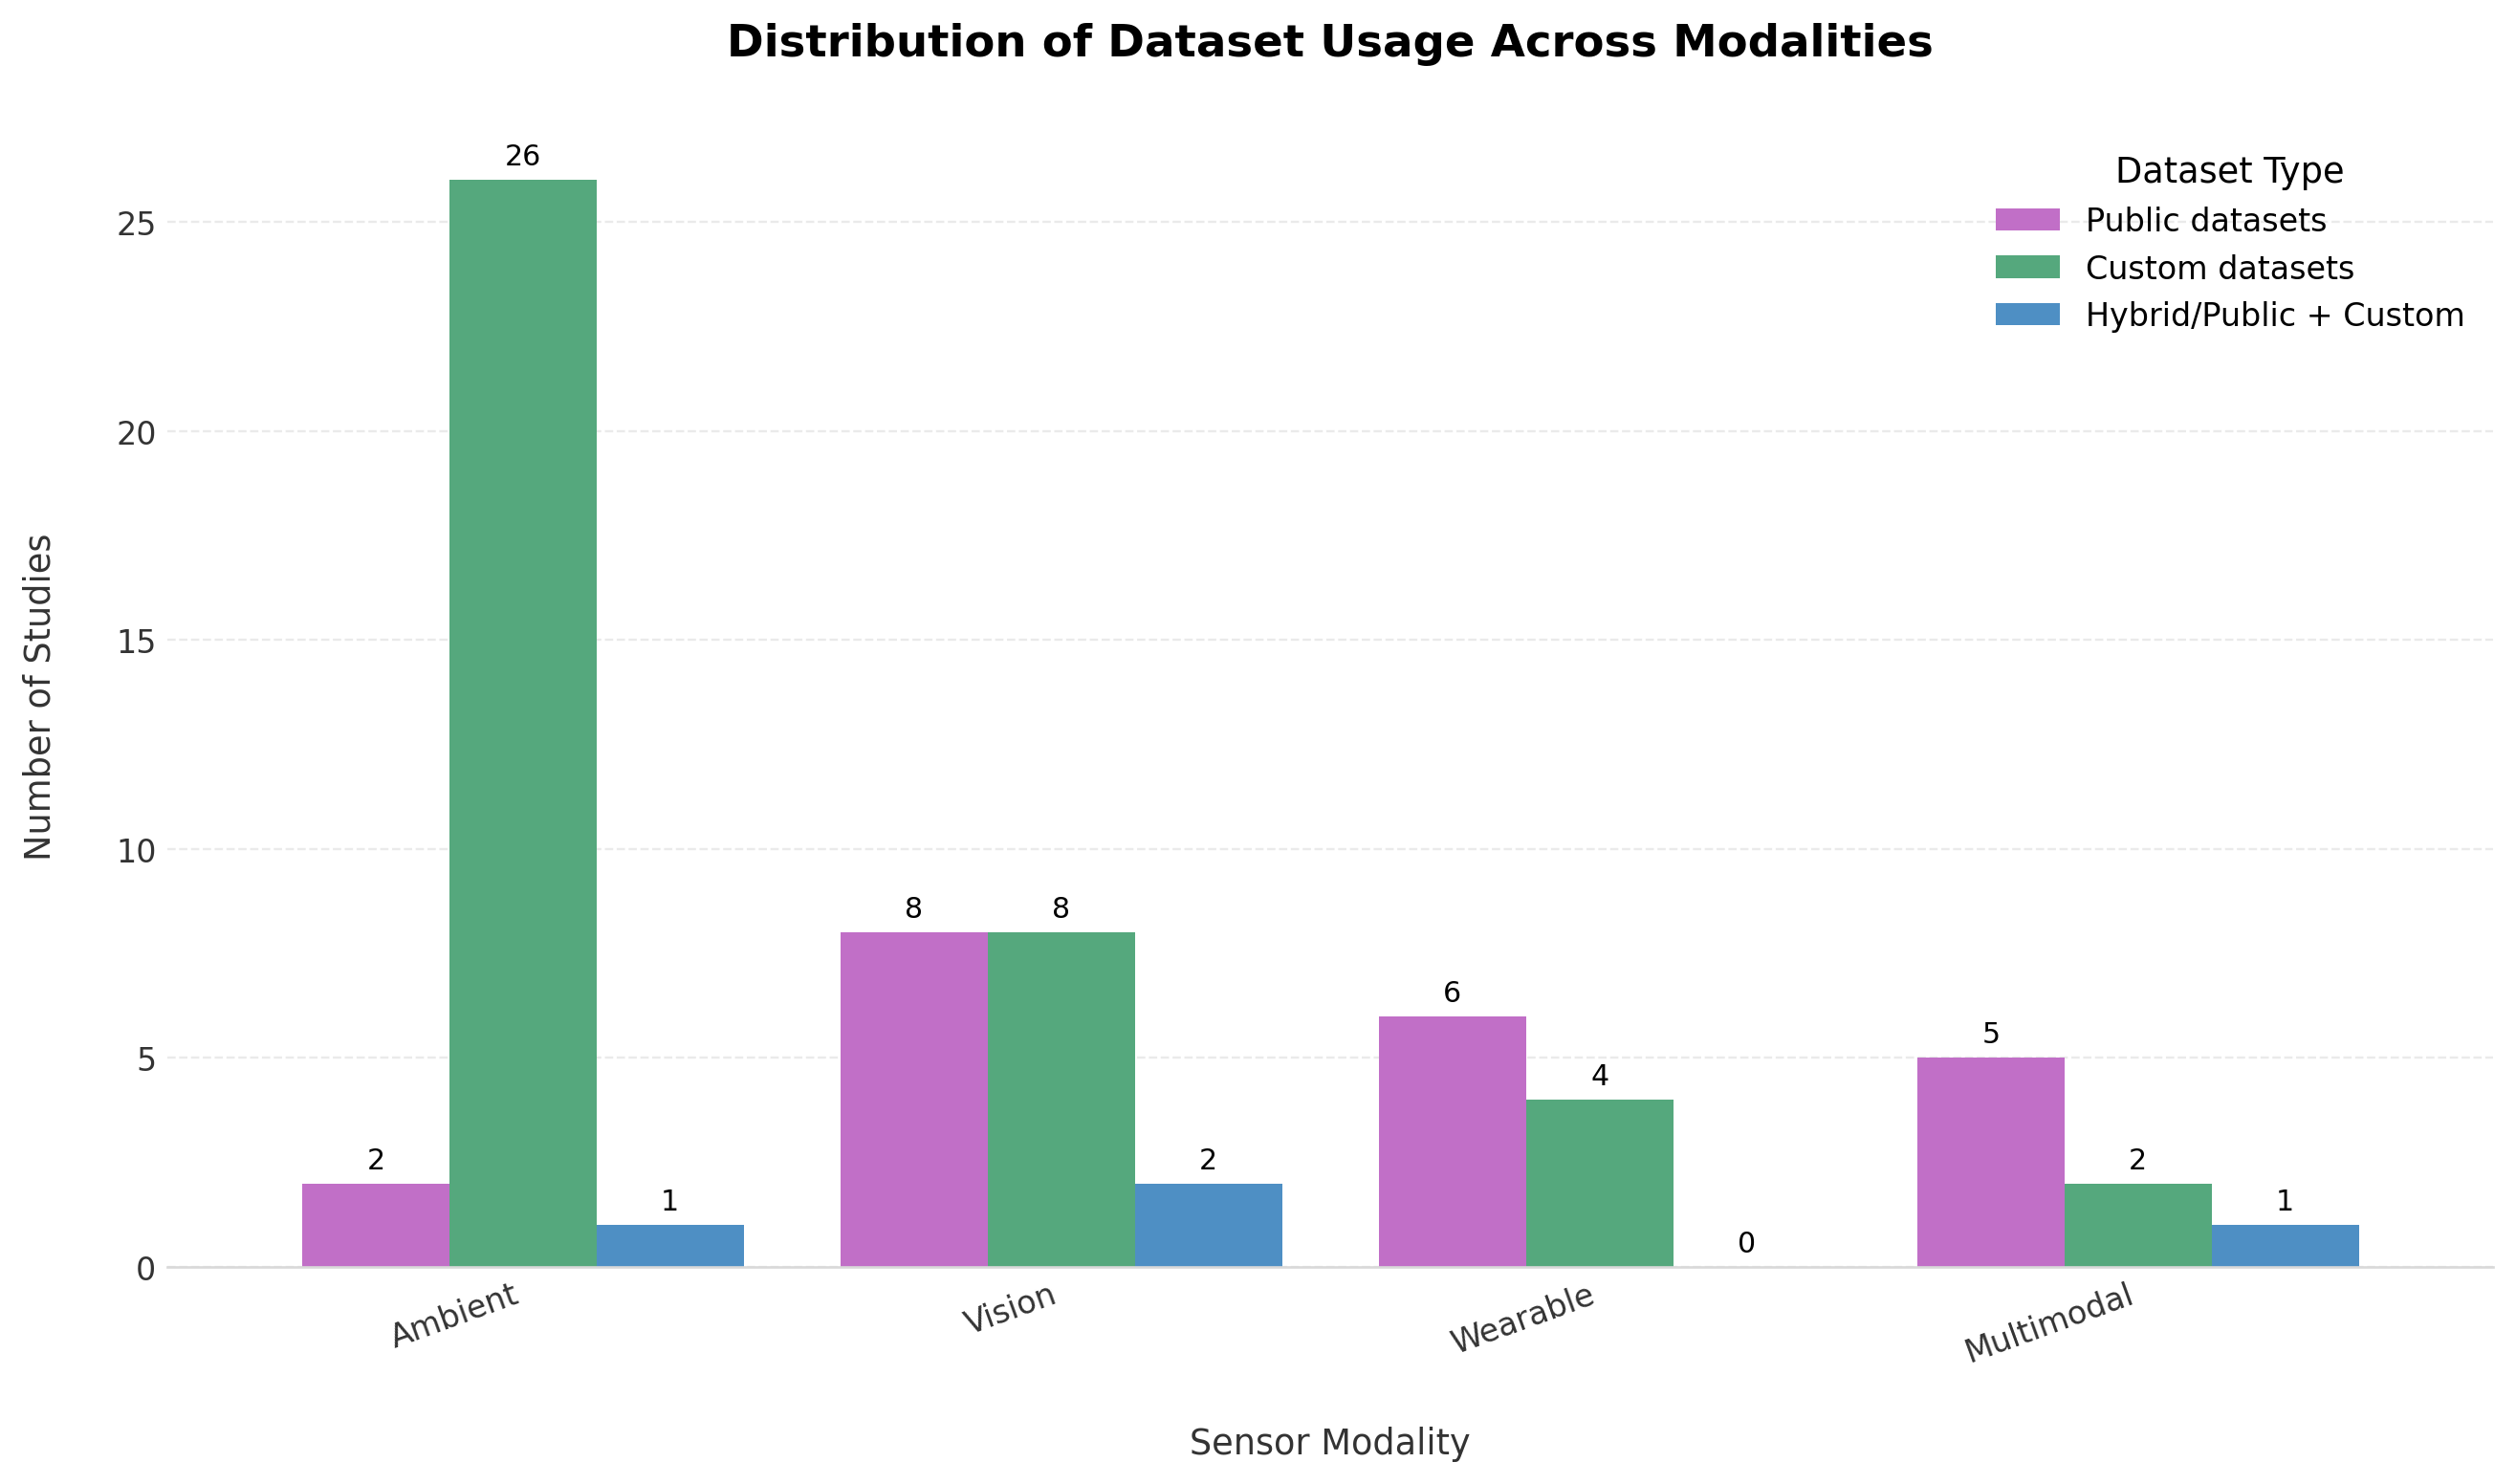

In [30]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# FIGURE Y
# Distribution of dataset usage across modalities
# with MULTIMODAL category
# =========================================================

# ---------------------------------
# Keep relevant columns only
# ---------------------------------
modality_dataset_df = df[
    ["Sensor modality", "Dataset typ"]
].copy()

# ---------------------------------
# Clean modality column
# ---------------------------------
modality_dataset_df["Sensor modality"] = (
    modality_dataset_df["Sensor modality"]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# ---------------------------------
# Standardize dataset labels
# ---------------------------------
modality_dataset_df["Dataset typ"] = (
    modality_dataset_df["Dataset typ"]
    .astype(str)
    .str.strip()
    .replace({
        "Mix": "Hybrid/Public + Custom",
        "Public": "Public datasets",
        "Custom": "Custom datasets"
    })
)

# =========================================================
# CREATE MODALITY CATEGORY
# =========================================================

def classify_modality(modality):

    modality = str(modality).strip()

    # If multiple modalities exist
    if ";" in modality:
        return "Multimodal"

    return modality

# ---------------------------------
# Apply classification
# ---------------------------------
modality_dataset_df["Modality"] = (
    modality_dataset_df["Sensor modality"]
    .apply(classify_modality)
)

# ---------------------------------
# Count dataset type per modality
# ---------------------------------
modality_counts = pd.crosstab(
    modality_dataset_df["Modality"],
    modality_dataset_df["Dataset typ"]
)

# ---------------------------------
# Reorder columns
# ---------------------------------
desired_order = [
    "Public datasets",
    "Custom datasets",
    "Hybrid/Public + Custom"
]

modality_counts = modality_counts.reindex(
    columns=desired_order,
    fill_value=0
)

# ---------------------------------
# Sort modalities by total count
# ---------------------------------
modality_counts = modality_counts.loc[
    modality_counts.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

print(modality_counts)

# =========================================================
# CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(11, 6.5))

# ---------------------------------
# Softer academic color palette
# ---------------------------------
colors = [
    "#C16FC7",   # muted blue
    "#55A87D",   # muted green
    "#4E8FC4"    # muted red
]

# ---------------------------------
# Create grouped bar plot
# ---------------------------------
modality_counts.plot(
    kind='bar',
    ax=ax,
    color=colors,
    width=0.82
)

# ---------------------------------
# Figure background
# ---------------------------------
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---------------------------------
# Clean axis appearance
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#D9D9D9')
ax.spines['left'].set_color('#D9D9D9')

# ---------------------------------
# Tick styling
# ---------------------------------
ax.tick_params(
    axis='both',
    which='both',
    length=0,
    labelsize=10
)

# ---------------------------------
# Grid styling
# ---------------------------------
ax.yaxis.grid(
    True,
    linestyle='--',
    linewidth=0.7,
    color="#EAEAEA"
)

ax.xaxis.grid(False)

# ---------------------------------
# Rotate x-axis labels
# ---------------------------------
plt.xticks(
    rotation=20,
    ha='right'
)

# ---------------------------------
# Labels and title
# ---------------------------------
ax.set_xlabel(
    "Sensor Modality",
    fontsize=11,
    labelpad=18
)

ax.set_ylabel(
    "Number of Studies",
    fontsize=11,
    labelpad=18
)

ax.set_title(
    "Distribution of Dataset Usage Across Modalities",
    fontsize=14,
    weight='bold',
    pad=22
)

# ---------------------------------
# Legend styling
# ---------------------------------
legend = ax.legend(
    title="Dataset Type",
    frameon=False,
    fontsize=10
)

legend.get_title().set_fontsize(11)

# ---------------------------------
# Add labels above bars
# ---------------------------------
for container in ax.containers:

    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

# ---------------------------------
# Improve layout
# ---------------------------------
fig.tight_layout()

# ---------------------------------
# Create output directory
# ---------------------------------
Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

# ---------------------------------
# Save figure
# ---------------------------------
plt.savefig(
    "data/figures/litRES/dataset_usage_by_modality_multimodal.png",
    dpi=300,
    bbox_inches="tight",
    facecolor='white'
)

# ---------------------------------
# Show plot
# ---------------------------------
plt.show()

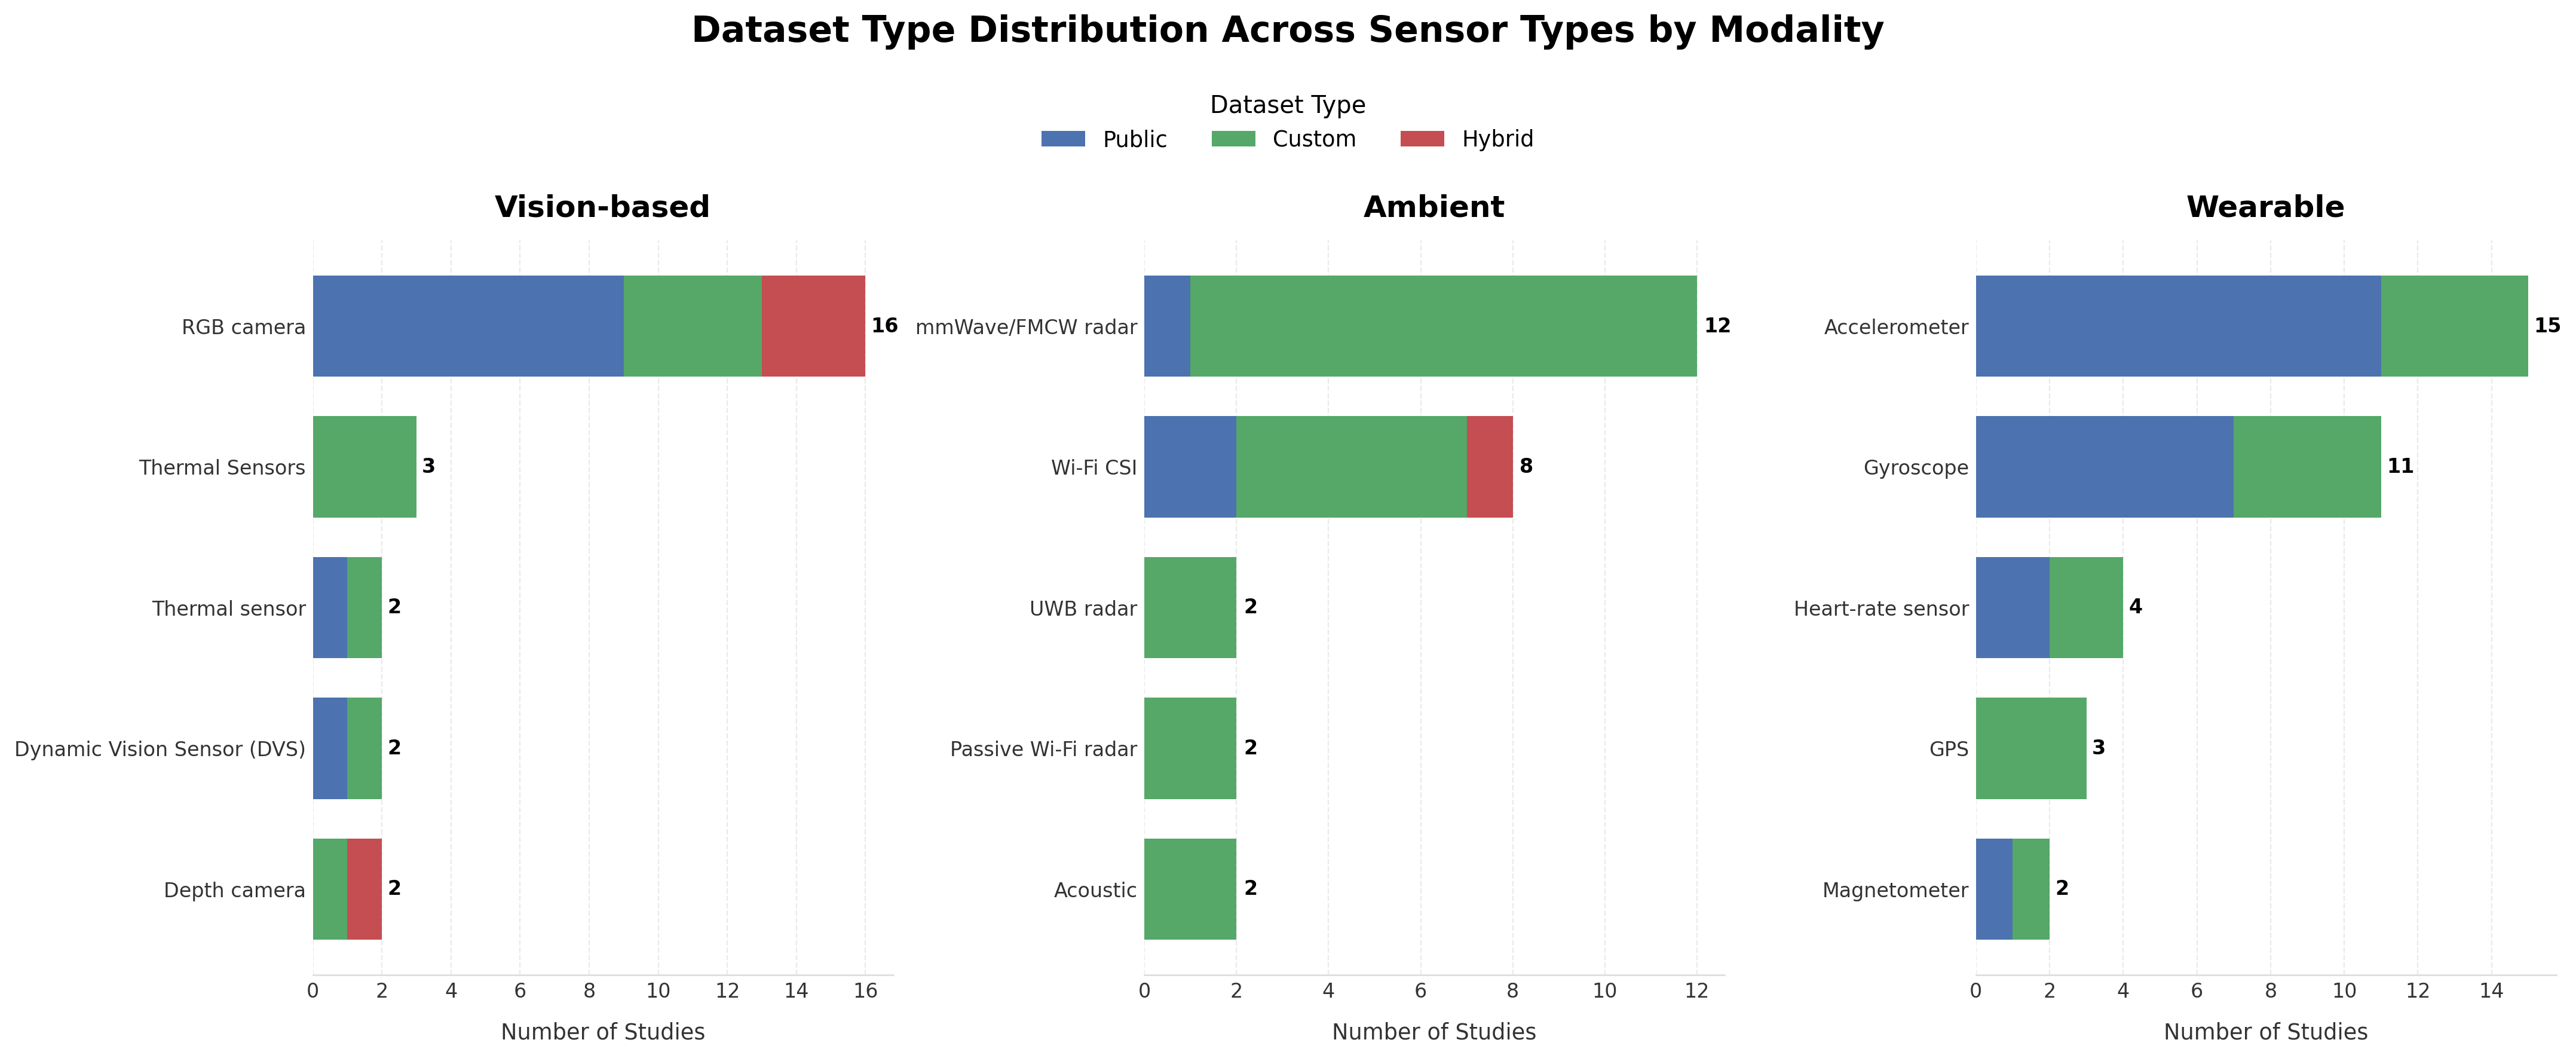

In [31]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# PUBLICATION-STYLE FIGURE
#
# Dataset type distribution across sensor types by modality
#
# FINAL DESIGN:
# - Horizontal stacked bars
# - Raw counts only
# - Multimodal systems decomposed
# - Sensor combinations decomposed
# - Top-N sensor types only
# - No "Other"
# - No multimodal panel
#
# PANELS:
# 1. Vision-based
# 2. Ambient
# 3. Wearable
# =========================================================

# ---------------------------------
# Keep relevant columns
# ---------------------------------
plot_df = df[
    ["Sensor modality", "Sensor type", "Dataset typ"]
].copy()

# =========================================================
# CLEAN COLUMNS
# =========================================================

for col in ["Sensor modality", "Sensor type", "Dataset typ"]:

    plot_df[col] = (
        plot_df[col]
        .astype(str)
        .str.replace(r'[\n\r\t]+', ' ', regex=True)
        .str.strip()
    )

# ---------------------------------
# Standardize dataset labels
# ---------------------------------
plot_df["Dataset typ"] = (
    plot_df["Dataset typ"]
    .replace({
        "Public": "Public",
        "Custom": "Custom",
        "Mix": "Hybrid"
    })
)

# =========================================================
# DEFINE SENSOR CATEGORIES
# =========================================================

VISION_KEYWORDS = [
    "camera",
    "vision",
    "thermal",
    "dvs",
    "rgb",
    "depth"
]

AMBIENT_KEYWORDS = [
    "wifi",
    "wi-fi",
    "csi",
    "radar",
    "uwb",
    "acoustic",
    "pir",
    "mmwave",
    "fmcw"
]

WEARABLE_KEYWORDS = [
    "accelerometer",
    "gyroscope",
    "magnetometer",
    "imu",
    "heart-rate",
    "gps",
    "ecg",
    "emg"
]

# =========================================================
# HELPER FUNCTION
# =========================================================

def categorize_sensor(sensor_name):

    sensor_name_lower = sensor_name.lower()

    # Vision
    if any(k in sensor_name_lower for k in VISION_KEYWORDS):
        return "Vision-based"

    # Ambient
    elif any(k in sensor_name_lower for k in AMBIENT_KEYWORDS):
        return "Ambient"

    # Wearable
    elif any(k in sensor_name_lower for k in WEARABLE_KEYWORDS):
        return "Wearable"

    return None

# =========================================================
# DECOMPOSE SENSOR COMBINATIONS
# =========================================================

expanded_rows = []

for _, row in plot_df.iterrows():

    dataset_type = row["Dataset typ"]

    # ---------------------------------
    # Split sensor combinations
    # ---------------------------------
    sensors = [
        s.strip()
        for s in str(row["Sensor type"]).split(";")
    ]

    # ---------------------------------
    # Add each sensor separately
    # ---------------------------------
    for sensor in sensors:

        modality_category = categorize_sensor(sensor)

        # Skip uncategorized sensors
        if modality_category is None:
            continue

        expanded_rows.append({
            "Sensor": sensor,
            "Modality": modality_category,
            "Dataset typ": dataset_type
        })

# ---------------------------------
# Create expanded dataframe
# ---------------------------------
expanded_df = pd.DataFrame(expanded_rows)

# =========================================================
# PARAMETERS
# =========================================================

target_modalities = [
    "Vision-based",
    "Ambient",
    "Wearable"
]

TOP_N = 5

dataset_order = [
    "Public",
    "Custom",
    "Hybrid"
]

colors = [
    "#4C72B0",   # muted blue
    "#55A868",   # muted green
    "#C44E52"    # muted red
]

# =========================================================
# CREATE FIGURE
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7),
    sharex=False
)

# =========================================================
# LOOP THROUGH MODALITIES
# =========================================================

for ax, modality in zip(axes, target_modalities):

    # ---------------------------------
    # Subset modality
    # ---------------------------------
    subset = expanded_df[
        expanded_df["Modality"] == modality
    ]

    # ---------------------------------
    # Top sensors
    # ---------------------------------
    top_sensors = (
        subset["Sensor"]
        .value_counts()
        .head(TOP_N)
        .index
    )

    subset = subset[
        subset["Sensor"]
        .isin(top_sensors)
    ]

    # ---------------------------------
    # Crosstab
    # ---------------------------------
    table = pd.crosstab(
        subset["Sensor"],
        subset["Dataset typ"]
    )

    # ---------------------------------
    # Reorder columns
    # ---------------------------------
    table = table.reindex(
        columns=dataset_order,
        fill_value=0
    )

    # ---------------------------------
    # Sort rows
    # ---------------------------------
    table = table.loc[
        table.sum(axis=1)
        .sort_values(ascending=True)
        .index
    ]

    # ---------------------------------
    # Plot
    # ---------------------------------
    table.plot(
        kind='barh',
        stacked=True,
        ax=ax,
        color=colors,
        width=0.72
    )

    # =====================================================
    # STYLING
    # =====================================================

    ax.set_title(
        modality,
        fontsize=15,
        weight='bold',
        pad=12
    )

    # ---------------------------------
    # Remove subplot legends
    # ---------------------------------
    ax.get_legend().remove()

    # ---------------------------------
    # Clean spines
    # ---------------------------------
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['bottom'].set_color('#DDDDDD')
    ax.spines['left'].set_color('#DDDDDD')

    # ---------------------------------
    # Grid
    # ---------------------------------
    ax.xaxis.grid(
        True,
        linestyle='--',
        linewidth=0.7,
        color="#EAEAEA"
    )

    ax.yaxis.grid(False)

    # ---------------------------------
    # Tick styling
    # ---------------------------------
    ax.tick_params(
        axis='both',
        which='both',
        length=0,
        labelsize=10
    )

    # ---------------------------------
    # Labels
    # ---------------------------------
    ax.set_xlabel(
        "Number of Studies",
        fontsize=11,
        labelpad=10
    )

    ax.set_ylabel("")

    # ---------------------------------
    # Add totals
    # ---------------------------------
    totals = table.sum(axis=1)

    for i, total in enumerate(totals):

        ax.text(
            total + 0.15,
            i,
            str(int(total)),
            va='center',
            fontsize=10,
            weight='bold'
        )

# =========================================================
# SHARED LEGEND
# =========================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Dataset Type",
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# =========================================================
# GLOBAL TITLE
# =========================================================

fig.suptitle(
    "Dataset Type Distribution Across Sensor Types by Modality",
    fontsize=18,
    weight='bold',
    y=1.04
)

# =========================================================
# LAYOUT
# =========================================================

fig.tight_layout(
    rect=[0, 0, 1, 0.93]
)

# =========================================================
# SAVE FIGURE
# =========================================================

Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/"
    "dataset_distribution_final_publication_style.png",
    dpi=300,
    bbox_inches="tight",
    facecolor='white'
)

# =========================================================
# SHOW
# =========================================================

plt.show()

Architecture Category
Local/on-device    35.0
Cloud-based         2.0
Hybrid             28.0
Name: count, dtype: float64


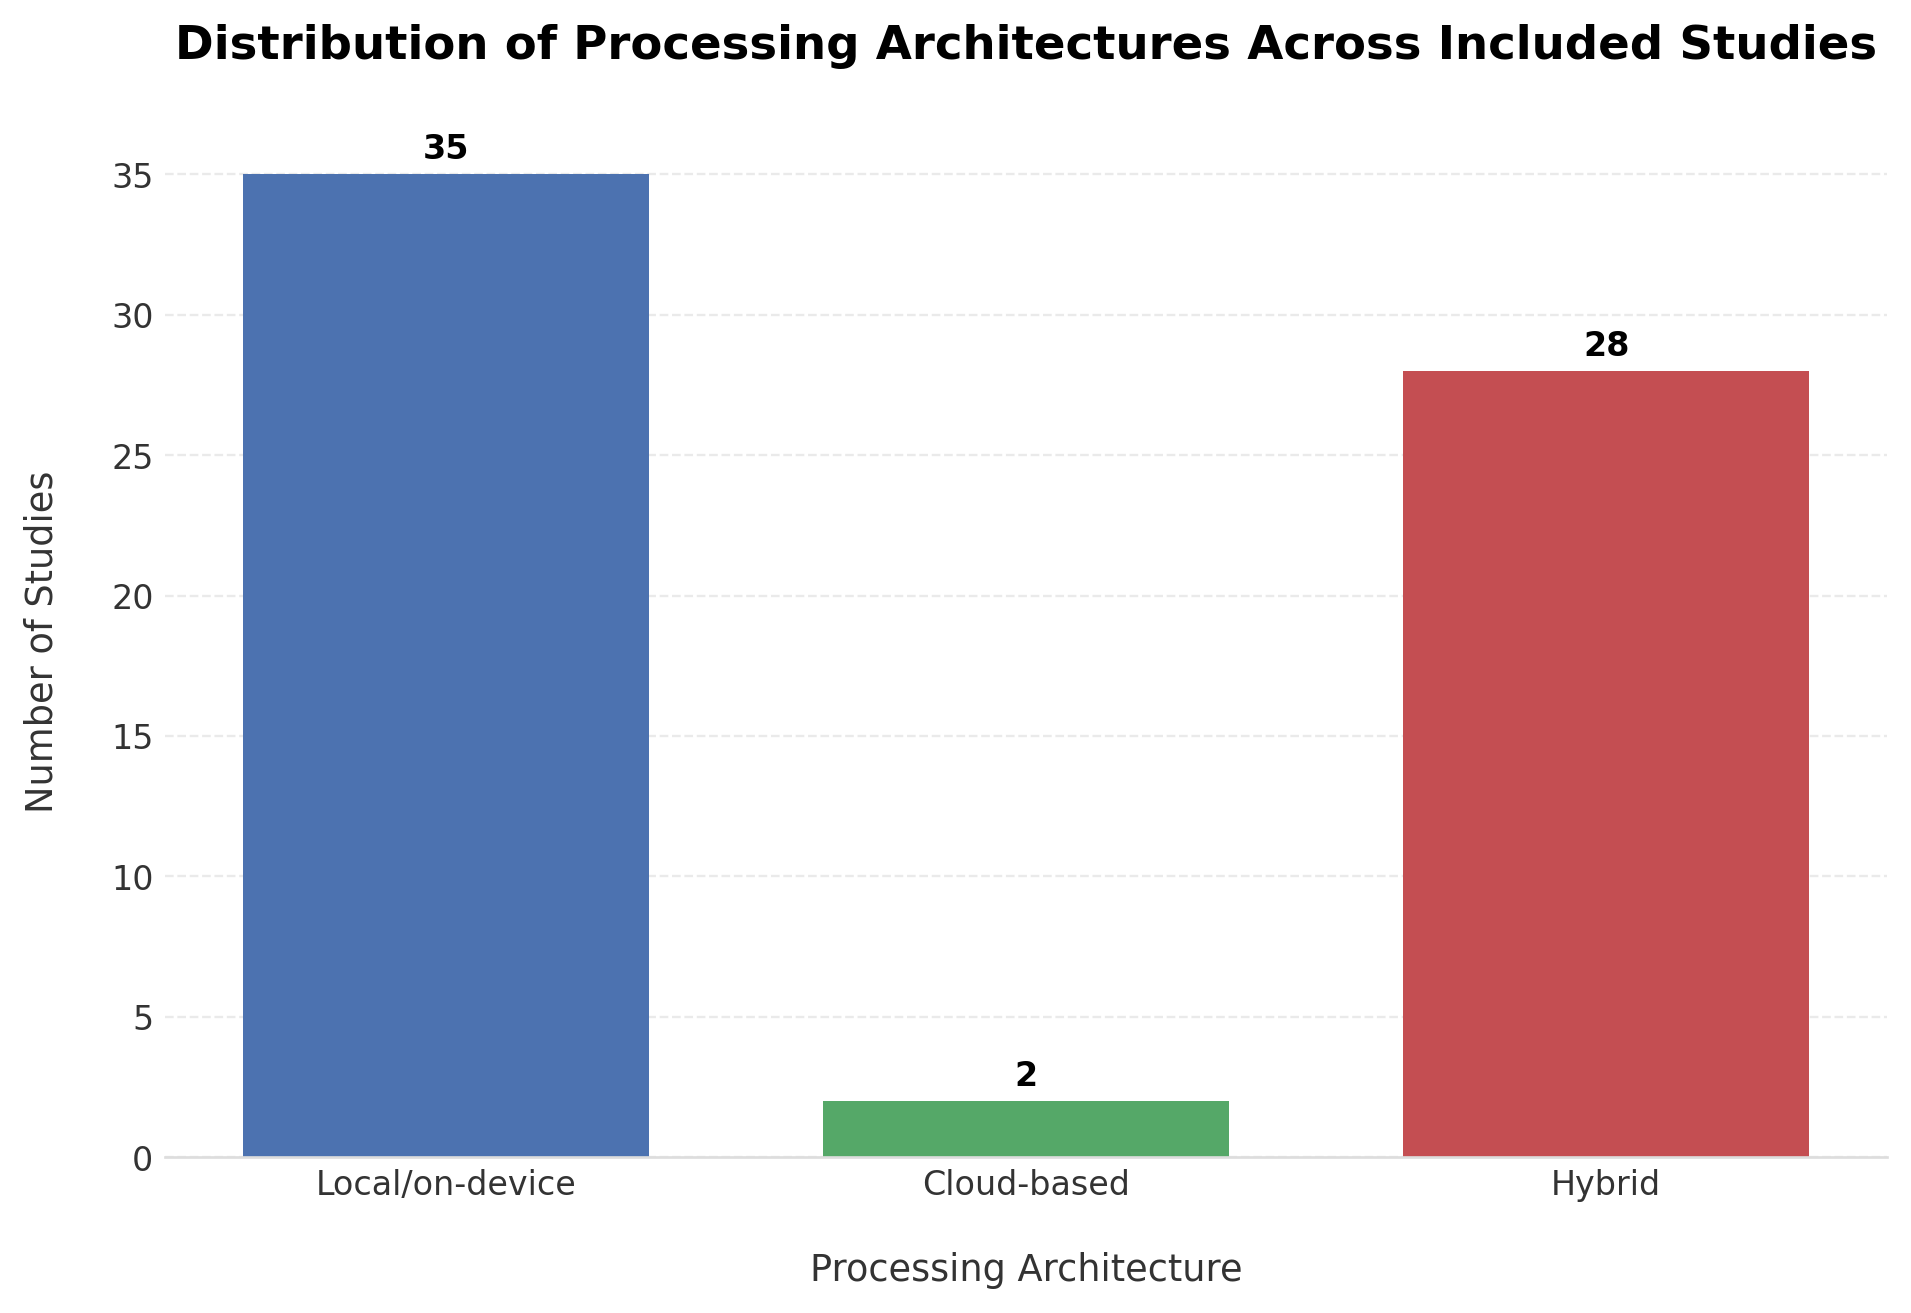

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# FIGURE X
# Distribution of Processing Architectures
# Across Included Studies
# =========================================================

# ---------------------------------
# Keep relevant column
# ---------------------------------
arch_df = df[
    ["Processing Architecture"]
].copy()

# ---------------------------------
# Clean text
# ---------------------------------
arch_df["Processing Architecture"] = (
    arch_df["Processing Architecture"]
    .astype(str)
    .str.replace(r'[\n\r\t]+', ' ', regex=True)
    .str.strip()
)

# =========================================================
# CLASSIFY ARCHITECTURES
# =========================================================

def classify_architecture(arch):

    arch_lower = str(arch).lower()

    # ---------------------------------
    # Hybrid systems
    # ---------------------------------
    if ";" in arch_lower:
        return "Hybrid"

    # ---------------------------------
    # Local / On-device
    # ---------------------------------
    elif "local" in arch_lower or "on-device" in arch_lower:
        return "Local/on-device"

    # ---------------------------------
    # Edge
    # ---------------------------------
    elif "edge" in arch_lower:
        return "Edge-based"

    # ---------------------------------
    # Cloud
    # ---------------------------------
    elif "cloud" in arch_lower:
        return "Cloud-based"

    return "Other"

# ---------------------------------
# Apply classification
# ---------------------------------
arch_df["Architecture Category"] = (
    arch_df["Processing Architecture"]
    .apply(classify_architecture)
)

# =========================================================
# COUNT CATEGORIES
# =========================================================

architecture_counts = (
    arch_df["Architecture Category"]
    .value_counts()
)

# ---------------------------------
# Reorder categories
# ---------------------------------
desired_order = [
    "Local/on-device",
    "Edge-based",
    "Cloud-based",
    "Hybrid"
]

architecture_counts = architecture_counts.reindex(
    desired_order
).dropna()

print(architecture_counts)

# =========================================================
# CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

# ---------------------------------
# Publication-style colors
# ---------------------------------
colors = [
    "#4C72B0",
    "#55A868",
    "#C44E52",
    "#8172B2"
]

# ---------------------------------
# Create bars
# ---------------------------------
bars = ax.bar(
    architecture_counts.index,
    architecture_counts.values,
    color=colors,
    width=0.7
)

# =========================================================
# STYLING
# =========================================================

# ---------------------------------
# Remove unnecessary spines
# ---------------------------------
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_color('#DDDDDD')
ax.spines['left'].set_color('#DDDDDD')

# ---------------------------------
# Tick styling
# ---------------------------------
ax.tick_params(
    axis='both',
    which='both',
    length=0,
    labelsize=10
)

# ---------------------------------
# Grid
# ---------------------------------
ax.yaxis.grid(
    True,
    linestyle='--',
    linewidth=0.7,
    color="#EAEAEA"
)

ax.xaxis.grid(False)

# ---------------------------------
# Labels
# ---------------------------------
ax.set_xlabel(
    "Processing Architecture",
    fontsize=11,
    labelpad=15
)

ax.set_ylabel(
    "Number of Studies",
    fontsize=11,
    labelpad=15
)

ax.set_title(
    "Distribution of Processing Architectures Across Included Studies",
    fontsize=14,
    weight='bold',
    pad=20
)

# =========================================================
# ADD VALUE LABELS
# =========================================================

for bar in bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold'
    )

# =========================================================
# LAYOUT
# =========================================================

fig.tight_layout()

# =========================================================
# SAVE FIGURE
# =========================================================

Path("data/figures/litRES").mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    "data/figures/litRES/"
    "processing_architecture_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor='white'
)

# =========================================================
# SHOW
# =========================================================

plt.show()